In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import signal

from load_hc3_session import load_hc3_session_full

In [4]:
data = load_hc3_session_full(
    base_path="E:",   
    topdir="ec012ec",
    session="ec012ec.189",
    load_lfp=True,
    load_position=True,
    verbose=True
)

print(f"✓ Loaded data!")

正在加载: ec012ec/ec012ec.189
E:ec012ec\ec012ec.189.tar.gz
xml_files: ['ec012ec.11/ec012ec.189/ec012ec.189.xml']
✓ XML 配置已加载
✓ channel:33 | sampling_rate:20000
✓ 位置数据: 36817 个时间点
✓ 提取了 25 个神经元单元
✓ LFP 数据已加载: 33 通道, 1178125 个采样点，采样率 1250
✓ LFP 942.50秒
加载完成！总 Spike 数量: 132,203
✓ Loaded data!


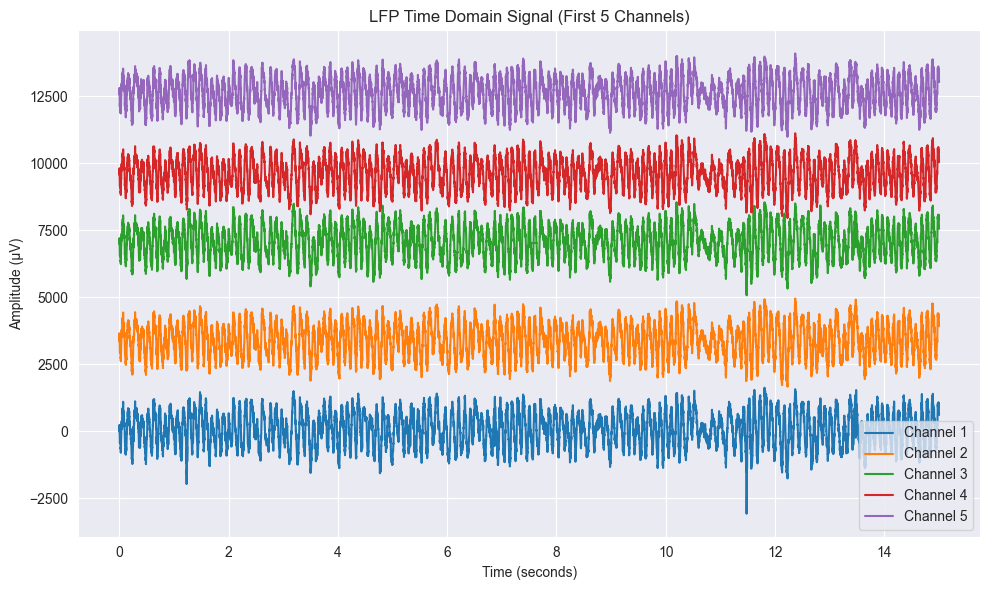

In [5]:
# ==================== LFP 时域信号 ====================
plt.figure(figsize=(10, 6))

lfp_data = data['lfp']['data']
fs = data['lfp']['sampling_rate']
t = data['lfp']['times_sec']

n_ch = min(5, lfp_data.shape[0])
duration = 15  # 显示多少秒，可修改

n_samples = int(duration * fs)

for ch in range(n_ch):
# for ch in range(7,12):
    sig = lfp_data[ch, :n_samples]
    offset = ch * (sig.max() - sig.min() + 50)   # 增加间距
    plt.plot(t[:n_samples], sig + offset, label=f'Channel {ch+1}')

plt.title('LFP Time Domain Signal (First 5 Channels)')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude (μV)')
plt.legend()
plt.tight_layout()
plt.show()

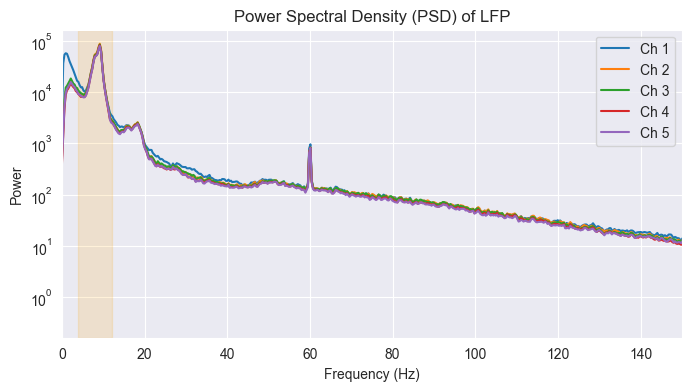

In [6]:
# ==================== PSD 功率谱 ====================
plt.figure(figsize=(8, 4))

n_ch = min(5, data['lfp']['data'].shape[0])

for ch in range(n_ch):
    f, pxx = signal.welch(data['lfp']['data'][ch], 
                         fs=data['lfp']['sampling_rate'], 
                         nperseg=4096, 
                         noverlap=2048)
    plt.semilogy(f, pxx, label=f'Ch {ch+1}')

plt.xlim(0, 150)
plt.title('Power Spectral Density (PSD) of LFP')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power')
plt.legend()
plt.axvspan(4, 12, alpha=0.15, color='orange', label='Theta (4-12 Hz)')
plt.grid(True)
plt.show()

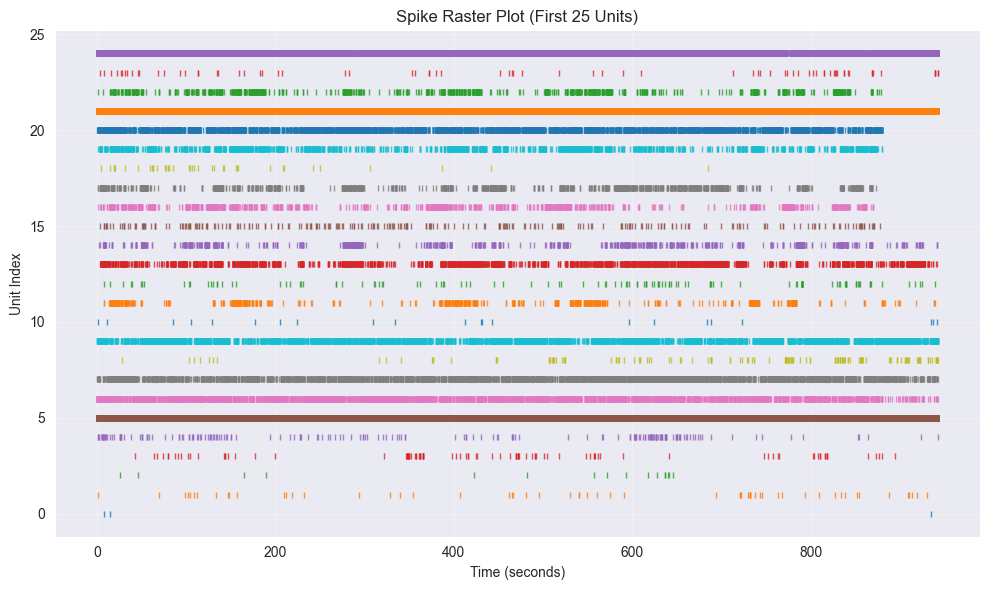

In [7]:
# ==================== Spike Raster Plot ====================
plt.figure(figsize=(10, 6))

units = sorted(list(data['spikes'].items()), 
               key=lambda x: (x[1]['electrode'], x[1]['cluster']))

colors = plt.cm.tab10(np.linspace(0, 1, 10))

for i, (key, unit) in enumerate(units[:40]):        # 可修改显示数量
    t_sec = unit['times_sec']
    color = colors[i % 10]
    plt.plot(t_sec, np.full_like(t_sec, i), '|', 
             color=color, markersize=4, alpha=0.8)

plt.title(f'Spike Raster Plot (First {min(40, len(units))} Units)')
plt.xlabel('Time (seconds)')
plt.ylabel('Unit Index')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

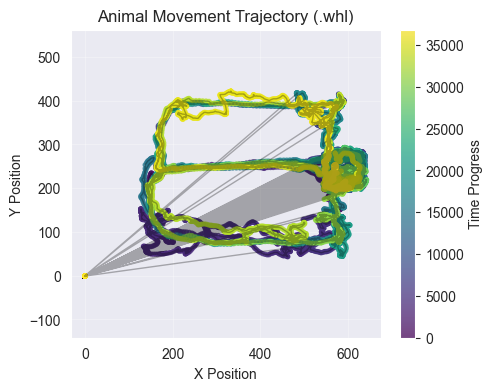

In [8]:
# ==================== 动物运动轨迹 ====================
if data.get('position') is not None:
    pos = data['position']
    plt.figure(figsize=(5, 4))
    
    # 轨迹线
    plt.plot(pos['x'], pos['y'], 'k-', alpha=0.3, linewidth=1)
    
    # 带时间颜色的散点
    scatter = plt.scatter(pos['x'], pos['y'], 
                         c=np.arange(len(pos)), 
                         cmap='viridis', 
                         s=8, alpha=0.7)
    
    plt.title('Animal Movement Trajectory (.whl)')
    plt.xlabel('X Position')
    plt.ylabel('Y Position')
    plt.colorbar(scatter, label='Time Progress')
    plt.axis('equal')
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("未找到位置数据 (.whl)")